# 16a · GSE232381 · bulk_RNA_seq · gap statistic: how many groups, if any?

Reads `expression.rds`, `metadata.rds` and the GSE65391 end product `module_genes.csv`.

**Matrix.** The same as the heatmaps (notebooks 17, 18): the 16 samples x the 10 GSE65391 hub genes
(highest kME in GSE65391) of each GSE65391 module that are measured here, each gene z-scored across
the 16 samples. With 16 samples, k up to 8 means clusters of about two samples on average.

**Method.** The gap statistic (Tibshirani R, Walther G, Hastie T. Estimating the number of clusters in
a data set via the gap statistic. *J R Stat Soc B* 2001;63:411-423). For each k, it compares the
within-cluster dispersion log(W_k) of the data with its expected value under a reference
distribution that has **no clusters**:

  Gap(k) = E*[log W_k] - log W_k

E* is estimated from B reference data sets drawn uniformly over the box aligned with the data's
principal components (`spaceH0 = "scaledPCA"`, one of the two reference distributions the paper proposes).

| setting | value | reason |
|---|---|---|
| k, patients | 1 to 8 | k = 1 is included, so "no structure" is a possible answer |
| k, genes | 1 to 20 | the genes are the hub genes of the GSE65391 modules (14 modules), so the gene axis has about 14 groups by construction; the range must extend past 14 for the answer to fall inside it |
| B | 500 reference data sets | the package default is 100; more reference sets reduce the Monte Carlo error of E*[log W_k] (the reported SE includes the factor the square root of (1 + 1/B)) |
| d.power | 2 | squared Euclidean distances; the `clusGap` documentation: `d.power = 2` "corresponds to what Tibshirani et al had proposed" (the default, 1, is the historical R implementation) |
| rule | `Tibs2001SEmax` | the paper's rule: the smallest k with Gap(k) >= Gap(k+1) - SE(k+1); it returns k = 1 when no larger k improves Gap by more than its standard error |

**Clustering method: k-means only**, on **both axes** (patients as observations; genes as
observations), 50 random starts.

**Why k-means only.** k, the number of clusters, is an input of k-means (Lloyd SP. Least squares
quantization in PCM. *IEEE Trans Inf Theory* 1982;28:129-137, doi:10.1109/TIT.1982.1056489; R's
`kmeans` uses Hartigan JA, Wong MA. Algorithm AS 136. *J R Stat Soc C* 1979;28:100-108,
doi:10.2307/2346830), so a rule for choosing k is needed and the gap statistic is such a rule. Ward's
hierarchical clustering (Ward JH. *J Am Stat Assoc* 1963;58:236-244, doi:10.1080/01621459.1963.10500845;
the `ward.D2` implementation: Murtagh F, Legendre P. *J Classif* 2014;31:274-295,
doi:10.1007/s00357-014-9161-z) has no k: its result is the whole tree. Cutting the tree at a chosen k
is an extra step the method does not make. Whether branches of the tree are supported is assessed
separately, by bootstrap (pvclust-py) and by tree shape (Dynamic Tree Cut), in their own notebooks.

The gap statistic is computed with `cluster::clusGap` (Maechler M et al., R package `cluster`),
which implements Tibshirani et al. (2001) and documents the settings below.

**Reading.** k = 1 means the data are no more clustered than the no-cluster reference.

## Build the matrix: samples by GSE65391 hub genes

In [1]:
source("../src/paths.R")
suppressMessages(library(cluster))
x    <- readRDS(art("GSE232381", "expression.rds"))
meta <- readRDS(art("GSE232381", "metadata.rds"))
mg   <- read.csv(art("GSE65391", "module_genes.csv"))
hub  <- do.call(rbind, lapply(split(mg, mg$module), function(d) head(d[order(-d$kME), ], 10)))
hub  <- hub$gene[hub$gene %in% rownames(x$E)]
X    <- scale(t(x$E[hub, meta$sample]))           # samples x genes, z-score per gene
X    <- X[, colSums(is.na(X)) == 0]
dim(X)

[1]  16 127

**Explanation**
- `module_genes.csv` of GSE65391 (notebook 05) lists each array gene's module and kME.
- For each module, `head(d[order(-d$kME), ], 10)` keeps the 10 genes with the highest kME: the hub genes.
  `order(-d$kME)` sorts from the highest kME.
- `hub$gene %in% rownames(x$E)` keeps the hub genes measured in this study.
- `scale(t(...))` z-scores each gene over the 16 samples; genes that do not vary are dropped.

## Run the gap statistic on both axes

In [2]:
km_fun   <- function(x, k) list(cluster = if (k == 1) rep(1L, nrow(x)) else kmeans(x, k, nstart = 50, iter.max = 100)$cluster)
gap_run  <- function(x, fun, K.max) { set.seed(SEED); clusGap(x, FUNcluster = fun, K.max = K.max, B = 500, d.power = 2, spaceH0 = "scaledPCA", verbose = FALSE) }
gaps <- list(
  "patients, k-means" = gap_run(X, km_fun, K.max = 8),
  "genes, k-means"    = gap_run(t(X), km_fun, K.max = 20))

**Explanation**
- As in notebook 06a. With 16 samples this cell takes about 1.5 minutes.

**Result table.** Gap(k) and its standard error for every k; the k chosen by the 1-SE rule.

## Gap for every k, and the k chosen

In [3]:
for (nm in names(gaps)) {
  g <- gaps[[nm]]$Tab
  print(data.frame(axis = nm, k = seq_len(nrow(g)), gap = round(g[, "gap"], 4), SE = round(g[, "SE.sim"], 4)))
}
chosen <- sapply(gaps, function(g) maxSE(g$Tab[, "gap"], g$Tab[, "SE.sim"], method = "Tibs2001SEmax"))
chosen

               axis k    gap     SE
1 patients, k-means 1 0.1373 0.1139
2 patients, k-means 2 0.0894 0.1072
3 patients, k-means 3 0.1088 0.1049
4 patients, k-means 4 0.1221 0.1069
5 patients, k-means 5 0.2029 0.1104
6 patients, k-means 6 0.2518 0.1154
7 patients, k-means 7 0.2985 0.1203
8 patients, k-means 8 0.3346 0.1264
             axis  k    gap     SE
1  genes, k-means  1 0.4505 0.0281
2  genes, k-means  2 0.5735 0.0279
3  genes, k-means  3 0.6014 0.0267
4  genes, k-means  4 0.6465 0.0270
5  genes, k-means  5 0.7057 0.0267
6  genes, k-means  6 0.7569 0.0267
7  genes, k-means  7 0.8190 0.0267
8  genes, k-means  8 0.8941 0.0266
9  genes, k-means  9 0.9525 0.0267
10 genes, k-means 10 0.9885 0.0268
11 genes, k-means 11 1.0326 0.0271
12 genes, k-means 12 1.0830 0.0268
13 genes, k-means 13 1.1111 0.0268
14 genes, k-means 14 1.1270 0.0270
15 genes, k-means 15 1.1571 0.0272
16 genes, k-means 16 1.1560 0.0273
17 genes, k-means 17 1.1571 0.0273
18 genes, k-means 18 1.1887 0.0272
19 genes, k

patients, k-means    genes, k-means 
                1                13

**Explanation**
- As in notebook 06a.

**Result.**
- **Patients: k = 1.** Gap is 0.137 at k = 1 and lower at k = 2 (0.089), so the rule stops at 1. Gap rises
  again from k = 5 to 0.335 at k = 8, but with 16 samples k = 8 means groups of about two, and the standard
  error is about 0.11. No grouping of the samples is supported.
- **Genes: the rule returns k = 13, but the curve does not level off.** Gap rises from 0.451 at k = 1 to
  1.111 at k = 13 and keeps rising slowly to 1.202 at k = 20. The rule stops at 13 because the gain from 13
  to 14 (0.016) is smaller than one standard error (0.027).

## Plot the gap curves

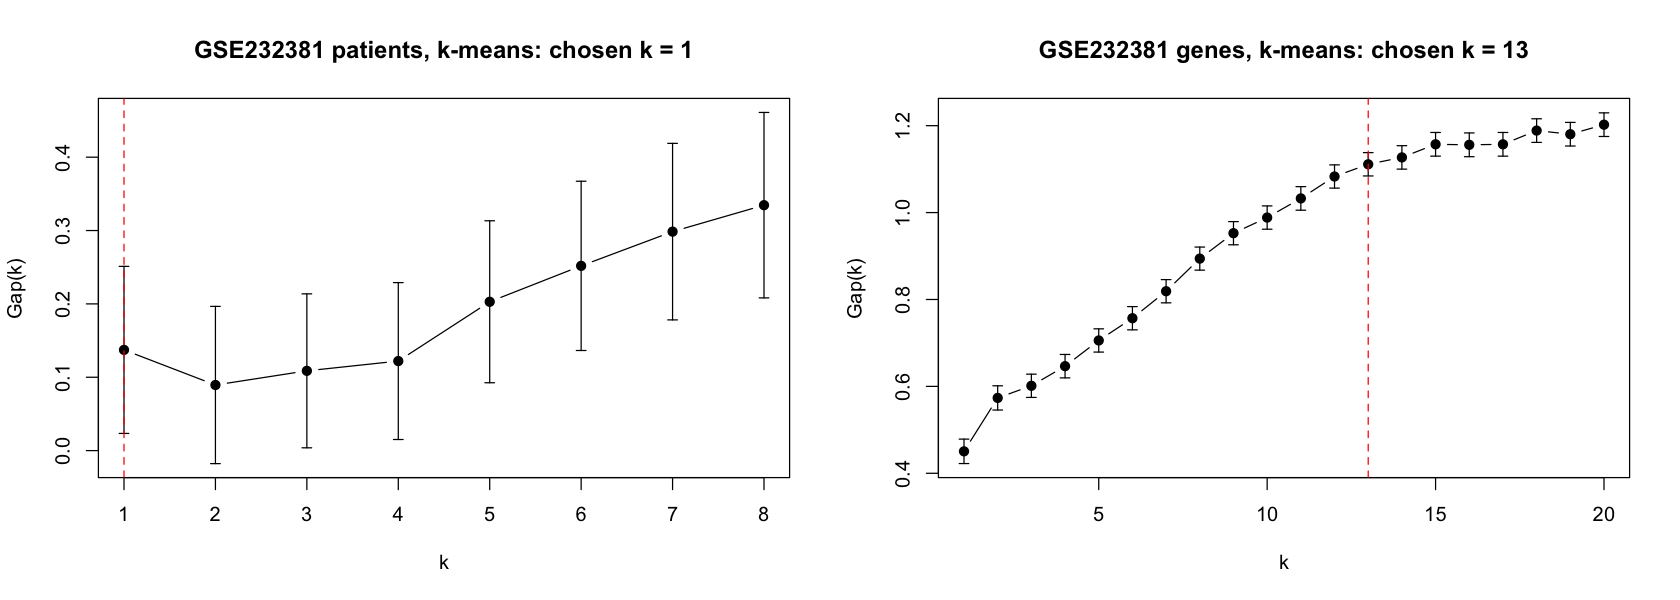

In [4]:
options(repr.plot.width = 14, repr.plot.height = 5)
figure <- function() {
  par(mfrow = c(1, 2))
  for (nm in names(gaps)) {
    g <- gaps[[nm]]$Tab
    k <- seq_len(nrow(g))
    plot(k, g[, "gap"], type = "b", pch = 19, ylim = range(g[, "gap"] + c(-1, 1) * max(g[, "SE.sim"])),
         xlab = "k", ylab = "Gap(k)", main = sprintf("GSE232381 %s: chosen k = %d", nm, chosen[[nm]]))
    arrows(k, g[, "gap"] - g[, "SE.sim"], k, g[, "gap"] + g[, "SE.sim"], angle = 90, code = 3, length = 0.04)
    abline(v = chosen[[nm]], lty = 2, col = "red")
  }
}
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE232381", "16a_GSE232381_bulk_RNA_seq_gap_statistic_1.png"), width = 14, height = 5, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- As in notebook 06a.

## Save

In [5]:
saveRDS(list(gaps = gaps, chosen = chosen), art("GSE232381", "gap_statistic.rds"))

**Explanation**
- `gap_statistic.rds` keeps both runs and the chosen k; notebook 18 reads it.